<a href="https://colab.research.google.com/github/MarkKryvoshein/MachineLearning/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install nltk

In [5]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [6]:
from nltk.corpus import movie_reviews
import random


lis_of_reviews = [(list(movie_reviews.words(fileid)), category) for category in movie_reviews.categories() for fileid in movie_reviews.fileids(category) ]

random.shuffle(lis_of_reviews)


print(lis_of_reviews[10])

(['let', 'me', 'begin', 'by', 'saying', 'that', 'this', 'is', 'easily', 'the', 'worst', 'movie', 'in', 'the', 'entire', 'official', '(', 'and', 'even', 'unofficial', ')', 'james', 'bond', 'series', '.', 'it', 'is', 'so', 'full', 'of', 'self', '-', 'parody', 'and', 'silly', 'characters', 'that', 'you', 'would', 'almost', 'believe', 'you', 'were', 'watching', 'a', 'spoof', '.', 'an', 'omen', 'of', 'what', 'is', 'to', 'come', 'is', 'provided', 'by', 'the', 'pre', '-', 'credits', 'sequence', ',', 'a', 'dull', 'affair', 'featuring', 'a', 'confrontation', 'between', 'a', 'man', '(', 'it', "'", 's', 'difficult', 'to', 'give', 'a', 'better', 'description', 'since', 'no', 'mention', 'of', 'him', 'is', 'made', 'elsewhere', 'in', 'the', 'movie', ')', 'and', 'the', 'assassin', 'of', 'the', 'title', '.', 'a', 'song', 'with', 'woefully', 'terrible', 'lyrics', 'follows', ',', 'and', 'the', 'rest', 'of', 'the', 'movie', 'is', 'even', 'worse', '.', 'the', 'plot', 'might', 'have', 'been', 'a', 'pleasant

In [27]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()


def clean_words() -> list:
    processed_reviews = []

    for words, category in lis_of_reviews:
        filtered = [
            ps.stem(w.lower())
            for w in words
            if w.isalpha() and w.lower() not in stop_words
        ]

        text = ' '.join(filtered)
        processed_reviews.append((text, category))

    return processed_reviews

print(clean_words()[0])

('sunday afternoon priviledg attend privat screen soni astor cinema new york citi jame cameron herald film titan postpon last summer escal budget make expens movi histori one film eager preview movi go sink swim holiday best guess sink though mani award attatch hull doubt titan elabor disast movi ever made boast amaz effect ever seen done date see ship fall apart actual peopl run across ship fli across deck fall water amaz look effect stunningli realist would swear look actual footag titan disast movi problem lie love stori attatch nearli ruin entir premis give capsul summari stori without spoil anyth film begin modern day excav sort sunken titan see actual footag sunken ship cammeron set special camera film wreckag ocean floor bill paxton lead expedit search sunken treasur find instead lead mysteri old woman recount tale titan voyag meet rose kate winslet young woman come upper class famili rose wed man love meet jack leonardo dicaprio young man come poor financi background win ticket

In [ ]:

#cleaned_document = [(" ".join(clean_words(doc), category) for doc, category in lis_of_reviews] якщо трреба буде в str

In [28]:
df = pd.DataFrame(clean_words(), columns=['review', 'label'])
df.head(10)

,review,label
0,sunday afternoon priviledg attend privat scree...,pos
1,great twelv month either princip movi earlier ...,neg
2,first film produc adam sandler happi madison p...,neg
3,plot bunch bad guy dress elvi imperson rob veg...,pos
4,regard make movi like tri stretch rubber band ...,pos
5,three long year sinc quentin tarantino stun ci...,pos
6,robert forster found famou appear jacki brown ...,neg
7,cop troubl person life ruthless villain friend...,neg
8,showgirl second major outing product team pual...,pos
9,five year directori debut base stephen king wr...,neg


<Axes: title={'center': 'Reviews data'}, xlabel='label'>

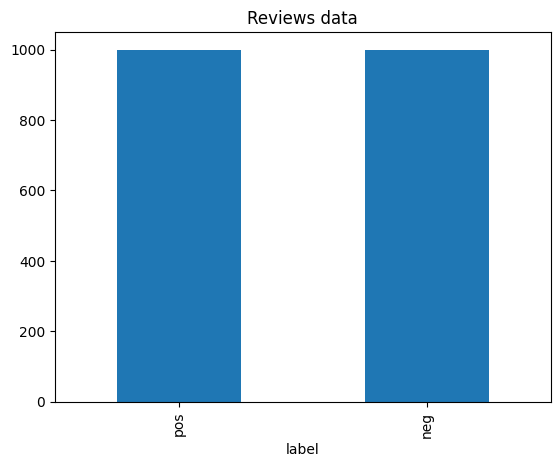

In [29]:
df['label'].value_counts().plot(kind='bar', title="Reviews data")

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])
y = df['label']

In [31]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 21560)	1
  (0, 301)	1
  (0, 17251)	1
  (0, 1171)	1
  (0, 17247)	1
  (0, 19406)	2
  (0, 20616)	1
  (0, 1118)	1
  (0, 3803)	1
  (0, 14992)	2
  (0, 25100)	1
  (0, 3833)	1
  (0, 11348)	1
  (0, 3088)	3
  (0, 9933)	1
  (0, 7714)	12
  (0, 22486)	13
  (0, 17019)	1
  (0, 12370)	1
  (0, 21549)	1
  (0, 7030)	1
  (0, 2785)	1
  (0, 13308)	2
  (0, 7247)	1
  (0, 14585)	10
  :	:
  (1999, 17845)	1
  (1999, 1691)	3
  (1999, 11105)	1
  (1999, 23425)	1
  (1999, 17095)	1
  (1999, 17865)	3
  (1999, 3089)	11
  (1999, 1232)	3
  (1999, 17094)	1
  (1999, 6772)	3
  (1999, 671)	1
  (1999, 15783)	1
  (1999, 1883)	1
  (1999, 14603)	1
  (1999, 24077)	1
  (1999, 22102)	1
  (1999, 4056)	2
  (1999, 11880)	1
  (1999, 4708)	1
  (1999, 24115)	3
  (1999, 10104)	1
  (1999, 6394)	1
  (1999, 21132)	1
  (1999, 19314)	1
  (1999, 21824)	1
0       pos
1       neg
2       neg
3       pos
4       pos
   

In [34]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

In [48]:
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

['pos' 'pos' 'neg' 'neg' 'neg' 'pos' 'pos' 'pos' 'neg' 'neg' 'pos' 'pos'
 'neg' 'neg' 'pos' 'neg' 'pos' 'neg' 'pos' 'neg' 'pos' 'neg' 'pos' 'pos'
 'pos' 'pos' 'pos' 'pos' 'pos' 'neg' 'neg' 'pos' 'pos' 'neg' 'pos' 'neg'
 'pos' 'neg' 'pos' 'pos' 'neg' 'neg' 'pos' 'pos' 'neg' 'neg' 'neg' 'pos'
 'neg' 'pos' 'pos' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg' 'neg' 'pos' 'neg'
 'pos' 'pos' 'pos' 'neg' 'neg' 'pos' 'neg' 'pos' 'neg' 'pos' 'neg' 'neg'
 'pos' 'neg' 'neg' 'neg' 'pos' 'pos' 'neg' 'neg' 'pos' 'neg' 'neg' 'pos'
 'neg' 'pos' 'neg' 'pos' 'pos' 'neg' 'neg' 'pos' 'pos' 'neg' 'neg' 'neg'
 'pos' 'neg' 'pos' 'neg' 'pos' 'pos' 'pos' 'pos' 'neg' 'neg' 'neg' 'pos'
 'neg' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg' 'neg' 'pos' 'pos' 'pos' 'neg'
 'neg' 'pos' 'pos' 'pos' 'neg' 'pos' 'neg' 'neg' 'neg' 'pos' 'neg' 'neg'
 'neg' 'neg' 'pos' 'pos' 'pos' 'pos' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg'
 'pos' 'neg' 'pos' 'pos' 'pos' 'pos' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg'
 'pos' 'pos' 'neg' 'pos' 'neg' 'neg' 'neg' 'neg' 'n

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("accurance:", accuracy_score(y_test, y_pred) )

accurance: 0.81


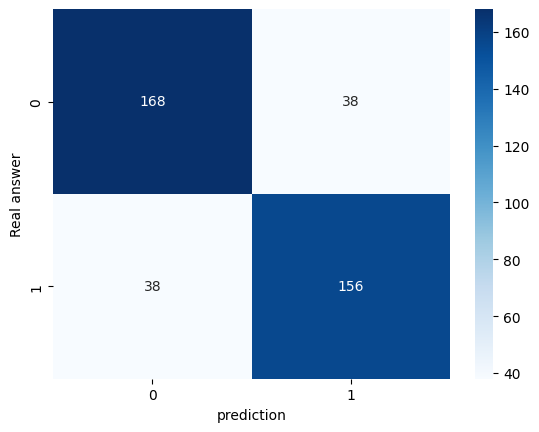

In [52]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap='Blues')
plt.xlabel("prediction")
plt.ylabel("Real answer")
plt.title("")
plt.show()